In [14]:
include(joinpath(@__DIR__, "../../", "readclassjson.jl"))
using LinearAlgebra
using Plots

![ProblemStatement](problem_statement.png)

![3a](3a.png)

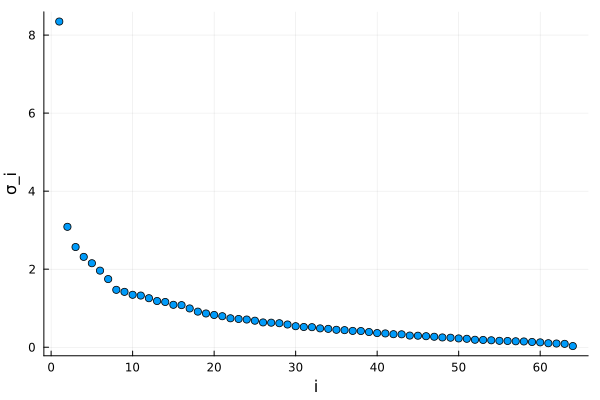

In [15]:
data = readclassjson("term_by_doc.json")

A = data["A"]
m = data["m"]
n = data["n"]

A_tilda = zeros((m,n))

for j in 1:n
    A_tilda[:,j] = A[:,j] / norm(A[:,j])
end

U, S, V = svd(A_tilda)

scatter(1:m, S, xlabel="i", ylabel="σ_i", legend=false)

![3b](3b.png)

In [16]:
q = zeros(m)
q[53] = 1
c = A_tilda' * q
sortedIdx = sortperm(c, rev=true)
result = "Top 5: $(sortedIdx[1:5])"


"Top 5: [106, 105, 107, 115, 111]"

![3c](3c.png)

In [ ]:
function find_low_rank_approx(matrix, r)
    U, S, V = svd(matrix)
    U_hat = U[:, 1:r]
    S_hat = diagm(S[1:r])
    V_hat = V[:, 1:r]
    A_hat = U_hat * S_hat * V_hat'
    return A_hat
end

A_hat_32 = find_low_rank_approx(A_tilda, 32)
A_hat_16 = find_low_rank_approx(A_tilda, 16)
A_hat_8 = find_low_rank_approx(A_tilda, 8)
A_hat_4 = find_low_rank_approx(A_tilda, 4)

q = zeros(m)
q[53] = 1
function query_students(matrix, matrix_name)
    c = matrix' * q
    sortedIdx = sortperm(c, rev=true)
    result = "$matrix_name has top 5 document results on query 'students': $(sortedIdx[1:5])"
    display(result)
    return result
end

query_students(A_hat_32, "A_hat_32")
query_students(A_hat_16, "A_hat_16")
query_students(A_hat_8, "A_hat_8")
query_students(A_hat_4, "A_hat_4")

"A_hat_4 has top 5 document results on query 'students': [115, 105, 107, 66, 63]"

"A_hat_4 has top 5 document results on query 'students': [115, 105, 107, 66, 63]"

![d](3d.png)

The low-rank approx is advantageous bc it requires less storage and computation time when compared to using the original term by document matrix to find the cosine similarity with the query